<a href="https://colab.research.google.com/github/vishalmahor886/eng_hindI_translation_project/blob/main/english_hindi_translation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [84]:
import pandas as pd
import numpy as np
import re
import string
import pickle
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, Model, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Dropout
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [85]:
# Tranining Hyperparameters
batch_size = 64

# Model Hyperparameters
embed_dim = 128
num_heads = 10
latent_dim = 2048
vocab_size = 20000
sequence_length = 20
dropout = 0.2

In [86]:
import re
import string

def preprocess_text(df):

    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    multi_space = re.compile(r'\s+')

    df["english_sent"] = (
        df["english_sent"]
        .str.lower()
        .str.replace(url_pattern, '', regex=True)
        .str.translate(str.maketrans('', '', string.digits))
        .str.replace(r'[^\w\s]', '', regex=True)   # remove punctuation
        .str.replace(multi_space, ' ', regex=True)
        .str.strip()
    )

    df["hindi_sent"] = (
        df["hindi_sent"]
        .str.lower()
        .str.replace(url_pattern, '', regex=True)
        .str.translate(str.maketrans('', '', string.digits))
        .str.replace(r'[a-zA-Z०-९]', '', regex=True)  # remove english + hindi digits
        .str.replace(r'[^\u0900-\u097F\s]', '', regex=True)
        .str.replace(multi_space, ' ', regex=True)
        .str.strip()
    )

    # Add start/end tokens
    df["hindi_sent"] = "[start] " + df["hindi_sent"] + " [end]"

    return df

In [87]:
# For creating Dataset
def format_dataset(eng, hin):
    eng = eng_vectorization(eng)
    hindi = hindi_vectorization(hin)
    return ({"encoder_inputs" : eng, "decoder_inputs" : hindi[:, :-1],}, hindi[:, 1:])

def make_dataset(df):
    dataset = tf.data.Dataset.from_tensor_slices((df["english_sent"].values, df["hindi_sent"].values))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset)
    return dataset.shuffle(2048).prefetch(16).cache()

In [115]:
def decode_sequence(input_sentence):
    hindi_vocab = hindi_vectorization.get_vocabulary()
    hindi_index_lookup = dict(zip(range(len(hindi_vocab)), hindi_vocab))
    max_decoded_sentence_length = 20

    tokenized_input_sentence = eng_vectorization([input_sentence])
    decoded_sentence = "[start]"
    for i in range(max_decoded_sentence_length):
        tokenized_target_sentence = hindi_vectorization([decoded_sentence])[:, :-1]
        predictions = transformer([tokenized_input_sentence, tokenized_target_sentence])

        sampled_token_index = np.argmax(predictions[0, i, :])
        sampled_token = hindi_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token

        if sampled_token == "[end]":
            break

    return decoded_sentence[8:-5] # Removing [start] and [end] toke

#Reading Data & Preprocessing Text

In [89]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Hindi_English_Truncated_Corpus.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "umasrikakollu72/hindi-english-truncated-corpus",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)


df.drop(columns=['source'], axis=1, inplace=True)
df.dropna(axis=0, inplace=True)
df.rename(columns={
    'english_sentence': 'english_sent',
    'hindi_sentence': 'hindi_sent'
}, inplace=True)
df.head()

/tmp/ipykernel_505/1040751968.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'hindi-english-truncated-corpus' dataset.


,english_sent,hindi_sent
0,politicians do not have permission to do what ...,"राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर..."
1,"I'd like to tell you about one such child,",मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहू...
2,This percentage is even greater than the perce...,यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।
3,what we really mean is that they're bad at not...,हम ये नहीं कहना चाहते कि वो ध्यान नहीं दे पाते
4,.The ending portion of these Vedas is called U...,इन्हीं वेदों का अंतिम भाग उपनिषद कहलाता है।


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 127605 entries, 0 to 127606
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   english_sent  127605 non-null  object
 1   hindi_sent    127605 non-null  object
dtypes: object(2)
memory usage: 2.9+ MB


In [91]:
preprocess_text(df)

# Drop rows with Null values
df.drop(df[df["english_sent"] == " "].index, inplace = True)
df.drop(df[df["hindi_sent"] == "[start]  [end]"].index, inplace = True)

In [92]:
## length

df['english_sent_len'] = df['english_sent'].str.split().str.len()
df['hindi_sent_len'] = df['hindi_sent'].str.split().str.len()

df.head()

,english_sent,hindi_sent,english_sent_len,hindi_sent_len
0,politicians do not have permission to do what ...,[start] राजनीतिज्ञों के पास जो कार्य करना चाहि...,12,15
1,id like to tell you about one such child,[start] मई आपको ऐसे ही एक बच्चे के बारे में बत...,9,13
2,this percentage is even greater than the perce...,[start] यह प्रतिशत भारत में हिन्दुओं प्रतिशत स...,10,11
3,what we really mean is that theyre bad at not ...,[start] हम ये नहीं कहना चाहते कि वो ध्यान नहीं...,12,13
4,the ending portion of these vedas is called up...,[start] इन्हीं वेदों का अंतिम भाग उपनिषद कहलात...,9,10


In [93]:
##

df = df[df['english_sent_len']<=20]
df = df[df['hindi_sent_len']<=20]

# Take 85K records for training
df = df.sample(n = 85000, random_state = 2048)
df = df.reset_index(drop = True)

train = df.iloc[:80000]
val = df.iloc[80000:84500]
test = df.iloc[84500:]

#Tokenizing Sentences

In [94]:
strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "").replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(lowercase, "[%s]" % re.escape(strip_chars), "")

In [95]:
## tokenization

eng_vectorization = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
)


hindi_vectorization = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)

eng_vectorization.adapt(df["english_sent"].values)
hindi_vectorization.adapt(df["hindi_sent"].values)

In [96]:
# Savng parameters and weights of both vectorizer
pickle.dump({'config': eng_vectorization.get_config(),
             'weights': eng_vectorization.get_weights()}
            , open("eng_vectorizer.pkl", "wb"))

pickle.dump({'config': hindi_vectorization.get_config(),
             'weights': hindi_vectorization.get_weights()}
            , open("hindi_vectorizer.pkl", "wb"))

In [97]:
train_ds = make_dataset(train)
val_ds = make_dataset(val)

In [98]:
train_ds

<CacheDataset element_spec=({'encoder_inputs': TensorSpec(shape=(None, 20), dtype=tf.int64, name=None), 'decoder_inputs': TensorSpec(shape=(None, 20), dtype=tf.int64, name=None)}, TensorSpec(shape=(None, 20), dtype=tf.int64, name=None))>

#Creating Model

In [99]:


class PositionalEmbedding(layers.Layer):
  def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
    super(PositionalEmbedding, self).__init__(**kwargs)
    self.sequence_length = sequence_length
    self.vocab_size = vocab_size
    self.embed_dim = embed_dim
    self.token_embedding = layers.Embedding(
        input_dim=vocab_size, output_dim=embed_dim,
        mask_zero=True
    )
    self.position_embedding = layers.Embedding(
        input_dim=sequence_length, output_dim=embed_dim
    )
  def call(self, inputs):
    length = tf.shape(inputs)[-1]
    positions = tf.range(start = 0, limit = length, delta = 1)
    embedded_token = self.token_embedding(inputs)
    embedded_position = self.position_embedding(positions)
    return embedded_token + embedded_position

In [100]:
class TransformerEncoder(layers.Layer):
  def __init__(self, embed_dim, dense_dim, num_heads, dropout, **kwargs):
    super(TransformerEncoder, self).__init__(**kwargs)
    self.embed_dim = embed_dim
    self.dense_dim = dense_dim
    self.num_heads = num_heads
    self.dropout = dropout
    self.attention = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=embed_dim
    )
    self.layer_norm1 = layers.LayerNormalization()
    self.layer_norm2 = layers.LayerNormalization()
    self.layer_ffn = Sequential(
        [Dense(dense_dim, activation="relu"),
         Dropout(dropout),
         Dense(embed_dim)
         ]
    )
    self.supports_masking = True


  def call(self, inputs, mask = None):
        if mask is not None:
            padding_mask = tf.cast(mask[:, tf.newaxis, tf.newaxis, :], dtype="int32")
        else:
            padding_mask = None
        attention_output = self.attention(
            query = inputs, value = inputs, key = inputs, attention_mask = padding_mask
        )
        ffn_input = self.layer_norm1(inputs + attention_output)
        ffn_output = self.layer_ffn(ffn_input)
        return self.layer_norm2(ffn_input + ffn_output)


In [101]:
class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, latent_dim, num_heads, dropout,**kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.embed_dim = embed_dim
        self.latent_dim = latent_dim
        self.num_heads = num_heads
        self.dropout = dropout
        self.attention1 = layers.MultiHeadAttention(
            num_heads = num_heads, key_dim = embed_dim
        )
        self.attention2 = layers.MultiHeadAttention(
            num_heads = num_heads, key_dim = embed_dim
        )
        self.layer_ffn = Sequential(
            [layers.Dense(latent_dim, activation="relu"),
             layers.Dropout(dropout),
             layers.Dense(embed_dim),]
        )
        self.layer_norm1 = layers.LayerNormalization()
        self.layer_norm2 = layers.LayerNormalization()
        self.layer_norm3 = layers.LayerNormalization()

        self.supports_masking = True



    def call(self, inputs, encoder_outputs, mask = None):
        causal_mask = self.get_causal_attention_mask(inputs)
        if mask is not None:
          padding_mask = tf.cast(mask[:, tf.newaxis, :], dtype="int32")
          padding_mask = tf.minimum(padding_mask, causal_mask)
        else:
          padding_mask = None
        attention_output1 = self.attention1(
            query=inputs, value=inputs, key=inputs, attention_mask=causal_mask
        )
        out1 = self.layer_norm1(inputs + attention_output1)

        attention_output2 = self.attention2(
            query = out1, value = encoder_outputs, key = encoder_outputs, attention_mask = padding_mask
        )
        out2 = self.layer_norm2(out1 + attention_output2)

        ffn_output = self.layer_ffn(out2)
        return self.layer_norm3(out2 + ffn_output)

    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        mult = tf.concat(
            [tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)],
            axis=0,
        )
        return tf.tile(mask, mult)

In [102]:
encoder_inputs = tf.keras.Input(shape=(None,), dtype="int64", name="encoder_inputs")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(encoder_inputs)
encoder_outputs = TransformerEncoder(embed_dim, latent_dim, num_heads, dropout,name="encoder_1")(x)
encoder = Model(encoder_inputs, encoder_outputs)

decoder_inputs = Input(shape=(None,), dtype="int64", name="decoder_inputs")
encoded_seq_inputs = Input(shape=(None, embed_dim), name="decoder_state_inputs")
x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(decoder_inputs)
x = TransformerDecoder(embed_dim, latent_dim, num_heads, dropout,name="decoder_1")(x, encoded_seq_inputs)
x = layers.Dropout(0.4)(x)
decoder_outputs = layers.Dense(vocab_size, activation="softmax")(x)
decoder = Model([decoder_inputs, encoded_seq_inputs], decoder_outputs)

decoder_outputs = decoder([decoder_inputs, encoder_outputs])
transformer = Model(
    [encoder_inputs, decoder_inputs], decoder_outputs, name="transformer"
)

In [103]:
transformer.summary()

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 128) │  2,562,560 │ encoder_inputs[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_1           │ (None, None, 128) │  1,186,304 │ positional_embed… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_16       │ (None, None,      │  6,988,448 │ decoder_inputs[0… │
│ (Functional)        │ 20000)            │            │ encoder_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,737,312 (40.96 MB)

 Trainable params: 10,737,312 (40.96 MB)

 Non-trainable params: 0 (0.00 B)

In [105]:
# Defining callback functions
early_stopping = EarlyStopping(patience = 5,restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# Compiling model
transformer.compile(
    optimizer = "adam",
    loss="sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

# Training model
transformer.fit(train_ds, epochs = 30, validation_data = val_ds, callbacks = [early_stopping, reduce_lr])

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 68s 42ms/step - accuracy: 0.6109 - loss: 2.7386 - val_accuracy: 0.6380 - val_loss: 2.4377 - learning_rate: 0.0010
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.6505 - loss: 2.2859 - val_accuracy: 0.6664 - val_loss: 2.1361 - learning_rate: 0.0010
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.6816 - loss: 1.9534 - val_accuracy: 0.6837 - val_loss: 1.9676 - learning_rate: 0.0010
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.7077 - loss: 1.7066 - val_accuracy: 0.6985 - val_loss: 1.8712 - learning_rate: 0.0010
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.7290 - loss: 1.5239 - val_accuracy: 0.7058 - val_loss: 1.8137 - learning_rate: 0.0010
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.7459 - loss: 1.3838 - val_accuracy: 0.7121 - val_loss: 1.8186 - learning_rate: 0.0010
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accura

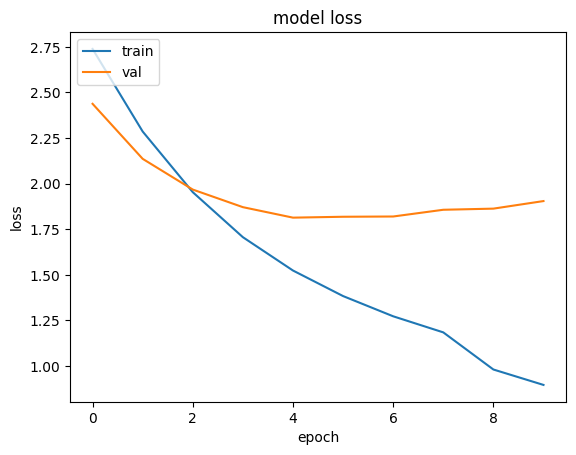

In [106]:
plt.plot(transformer.history.history['loss'])
plt.plot(transformer.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

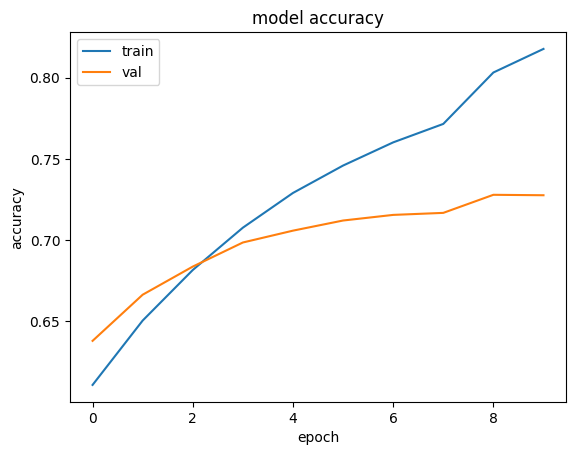

In [107]:
plt.plot(transformer.history.history['accuracy'])
plt.plot(transformer.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

In [108]:
# Saving weights of model
transformer.save_weights("eng-hin.weights.h5")

#Testing Model

In [120]:
# Sample for testing
eng = "i am at work"
print("English Sentence : ",eng)
print("Translated Sentence : ",decode_sequence(eng))

English Sentence :  i am at work
Translated Sentence :  मैं काम में रहा हूँ 


In [121]:
transformer.save("model.keras")